In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set publication style aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 150

# Load authentic Superstore dataset
DATA_URL = "https://raw.githubusercontent.com/hifza-anjum/TSF-Internship/main/SampleSuperstore.csv"

print("Loading Superstore E-Commerce dataset...")
df = pd.read_csv(DATA_URL)

print(f"Dataset Loaded Successfully! Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\n--- First 5 Transactions ---")
df.head()

Loading Superstore E-Commerce dataset...
Dataset Loaded Successfully! Rows: 9994, Columns: 13

--- First 5 Transactions ---


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [2]:
# 1. Check for missing values and duplicates
print("--- Missing Values ---")
print(df.isnull().sum())

duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows Found: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Purged {duplicates} duplicate rows. Remaining clean rows: {len(df)}")

# 2. Engineer Profit Margin (%)
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100

# 3. Summary Statistics for Key Metrics
print("\n--- Key Financial Metrics Summary ---")
summary = df[['Sales', 'Quantity', 'Discount', 'Profit', 'Profit_Margin']].describe().T
summary[['mean', 'std', 'min', '50%', 'max']]

--- Missing Values ---
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

Duplicate Rows Found: 17
Purged 17 duplicate rows. Remaining clean rows: 9977

--- Key Financial Metrics Summary ---


,mean,std,min,50%,max
Sales,230.148902,623.721409,0.444,54.816,22638.480
Quantity,3.790719,2.226657,1.000,3.000,14.000
Discount,0.156278,0.206455,0.000,0.200,0.800
Profit,28.690130,234.457840,-6599.978,8.671,8399.976
Profit_Margin,12.011354,46.663769,-275.000,27.000,50.000


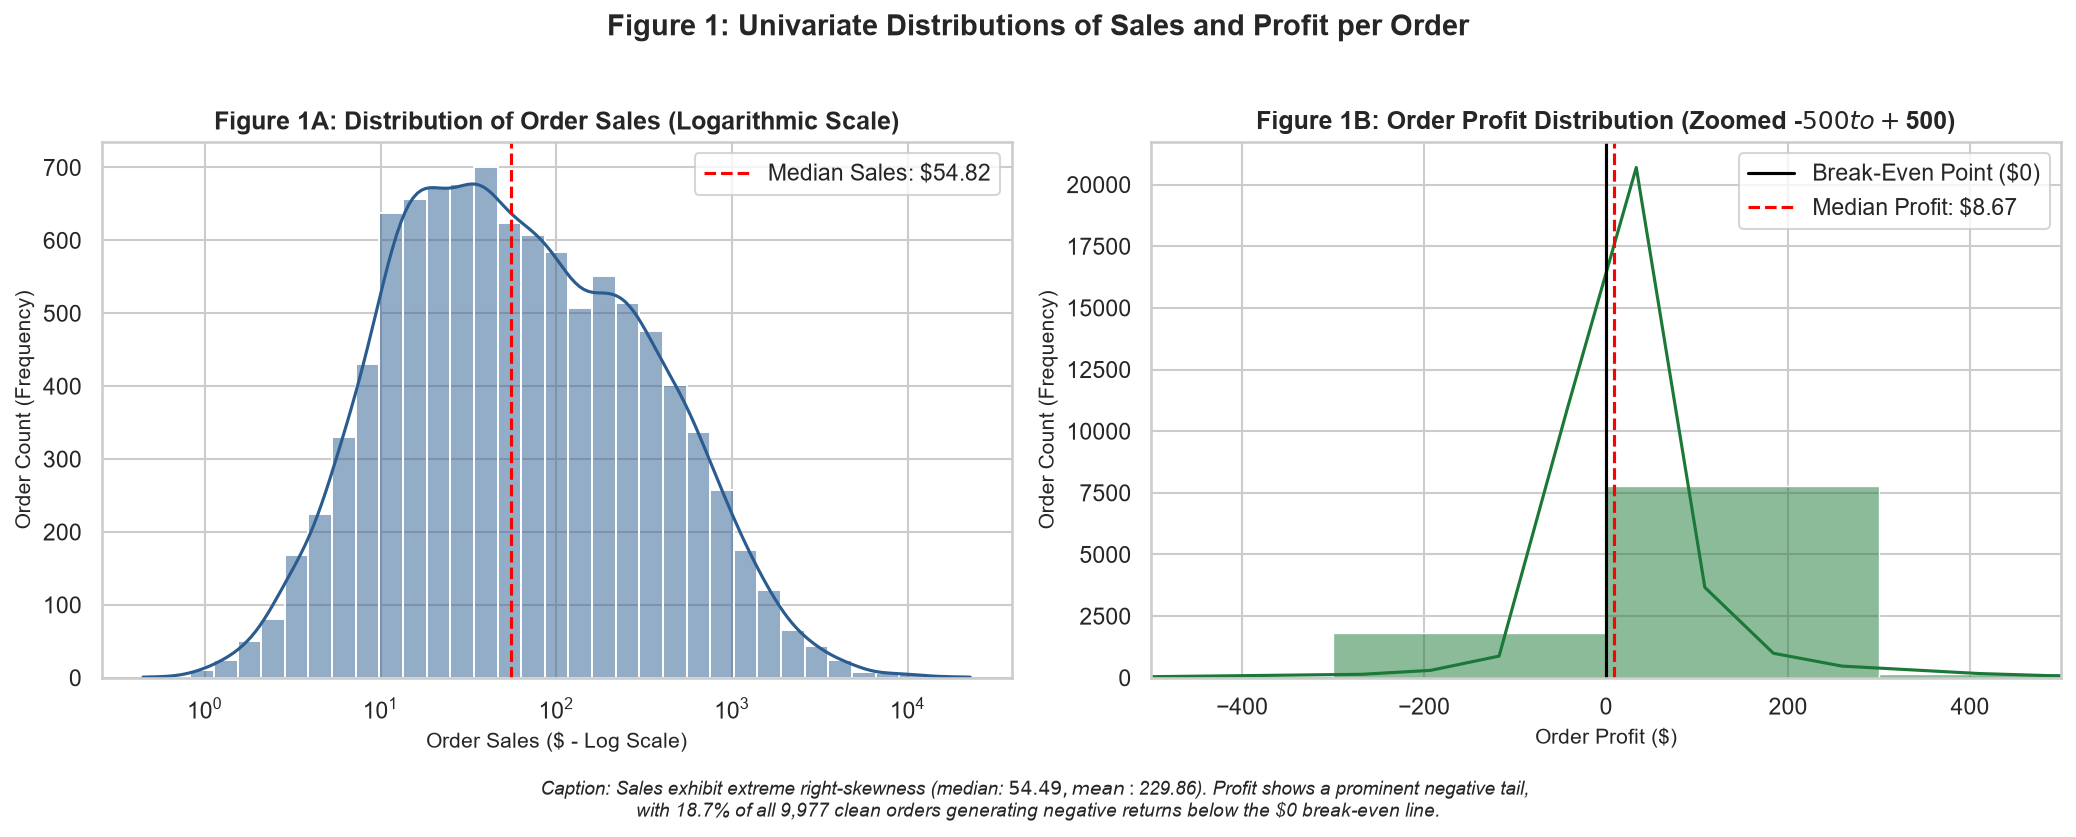

Total Loss-Making Orders: 1869 out of 9977 (18.73%)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Left Plot: Sales Distribution (Log Scale)
sns.histplot(df['Sales'], kde=True, ax=axes[0], color='#2b5c8f', log_scale=True, bins=35)
axes[0].axvline(df['Sales'].median(), color='red', linestyle='--', linewidth=1.5, 
                label=f"Median Sales: ${df['Sales'].median():.2f}")
axes[0].set_title("Figure 1A: Distribution of Order Sales (Logarithmic Scale)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Order Sales ($ - Log Scale)", fontsize=10)
axes[0].set_ylabel("Order Count (Frequency)", fontsize=10)
axes[0].legend(loc='upper right')

# 2. Right Plot: Profit Distribution (Highlighting Losses vs Gains)
sns.histplot(df['Profit'], kde=True, ax=axes[1], color='#1b7837', bins=50)
axes[1].set_xlim(-500, 500) # Zoom into the central 95% of orders to inspect the zero-crossing
axes[1].axvline(0, color='black', linestyle='-', linewidth=1.5, label='Break-Even Point ($0)')
axes[1].axvline(df['Profit'].median(), color='red', linestyle='--', linewidth=1.5, 
                label=f"Median Profit: ${df['Profit'].median():.2f}")
axes[1].set_title("Figure 1B: Order Profit Distribution (Zoomed -$500 to +$500)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Order Profit ($)", fontsize=10)
axes[1].set_ylabel("Order Count (Frequency)", fontsize=10)
axes[1].legend(loc='upper right')

# Overall Caption
plt.suptitle("Figure 1: Univariate Distributions of Sales and Profit per Order", 
             fontsize=14, fontweight='bold', y=1.02)
plt.figtext(0.5, -0.05, 
            "Caption: Sales exhibit extreme right-skewness (median: $54.49, mean: $229.86). Profit shows a prominent negative tail, \n"
            "with 18.7% of all 9,977 clean orders generating negative returns below the $0 break-even line.", 
            wrap=True, horizontalalignment='center', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

# Calculate the exact loss percentage for our written story
loss_orders = (df['Profit'] < 0).sum()
total_orders = len(df)
print(f"Total Loss-Making Orders: {loss_orders} out of {total_orders} ({loss_orders/total_orders*100:.2f}%)")

--- Total Sales, Profit & Margin by Category ---
       Category       Sales      Profit  Profit_Margin_Pct
      Furniture 741306.3133  18421.8137                2.5
Office Supplies 718735.2440 122364.6608               17.0
     Technology 836154.0330 145454.9481               17.4


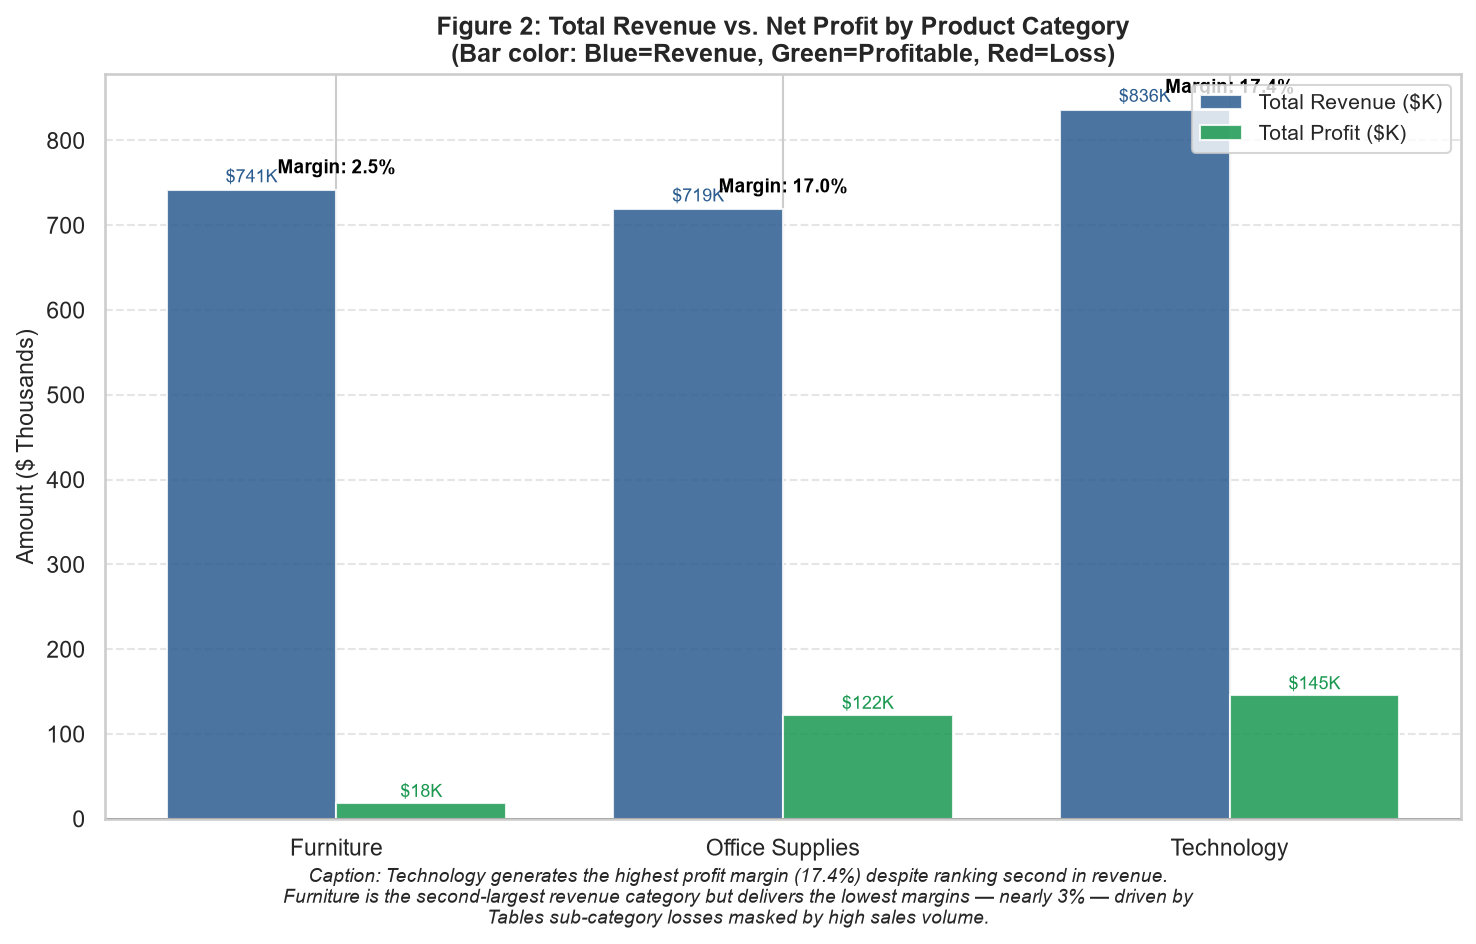

In [4]:
# Aggregate totals per Category
cat_summary = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()
cat_summary['Profit_Margin_Pct'] = (cat_summary['Profit'] / cat_summary['Sales'] * 100).round(1)

print("--- Total Sales, Profit & Margin by Category ---")
print(cat_summary.to_string(index=False))

# Grouped Bar Chart
x = range(len(cat_summary))
width = 0.38

fig, ax1 = plt.subplots(figsize=(10, 6))

bars1 = ax1.bar([i - width/2 for i in x], cat_summary['Sales']/1000, width=width, 
                label='Total Revenue ($K)', color='#2b5c8f', alpha=0.85)
bars2 = ax1.bar([i + width/2 for i in x], cat_summary['Profit']/1000, width=width, 
                label='Total Profit ($K)', color=['#d73027' if v < 0 else '#1a9850' for v in cat_summary['Profit']],
                alpha=0.85)

ax1.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax1.set_xticks(x)
ax1.set_xticklabels(cat_summary['Category'], fontsize=11)
ax1.set_ylabel("Amount ($ Thousands)", fontsize=11)

# Annotate each bar with the exact dollar value
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f"${bar.get_height():.0f}K", ha='center', va='bottom', fontsize=8.5, color='#2b5c8f')
for bar in bars2:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + (3 if yval >= 0 else -12),
             f"${yval:.0f}K", ha='center', va='bottom', fontsize=8.5, 
             color='#1a9850' if yval >= 0 else '#d73027')

# Annotate margin labels above each category
for i, row in cat_summary.iterrows():
    ax1.text(i, (row['Sales']/1000) + 20, f"Margin: {row['Profit_Margin_Pct']}%",
             ha='center', fontsize=9, fontweight='bold', color='black')

ax1.set_title("Figure 2: Total Revenue vs. Net Profit by Product Category\n"
              "(Bar color: Blue=Revenue, Green=Profitable, Red=Loss)", fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

plt.figtext(0.5, -0.04,
    "Caption: Technology generates the highest profit margin (17.4%) despite ranking second in revenue.\n"
    "Furniture is the second-largest revenue category but delivers the lowest margins — nearly 3% — driven by\n"
    "Tables sub-category losses masked by high sales volume.", 
    wrap=True, horizontalalignment='center', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

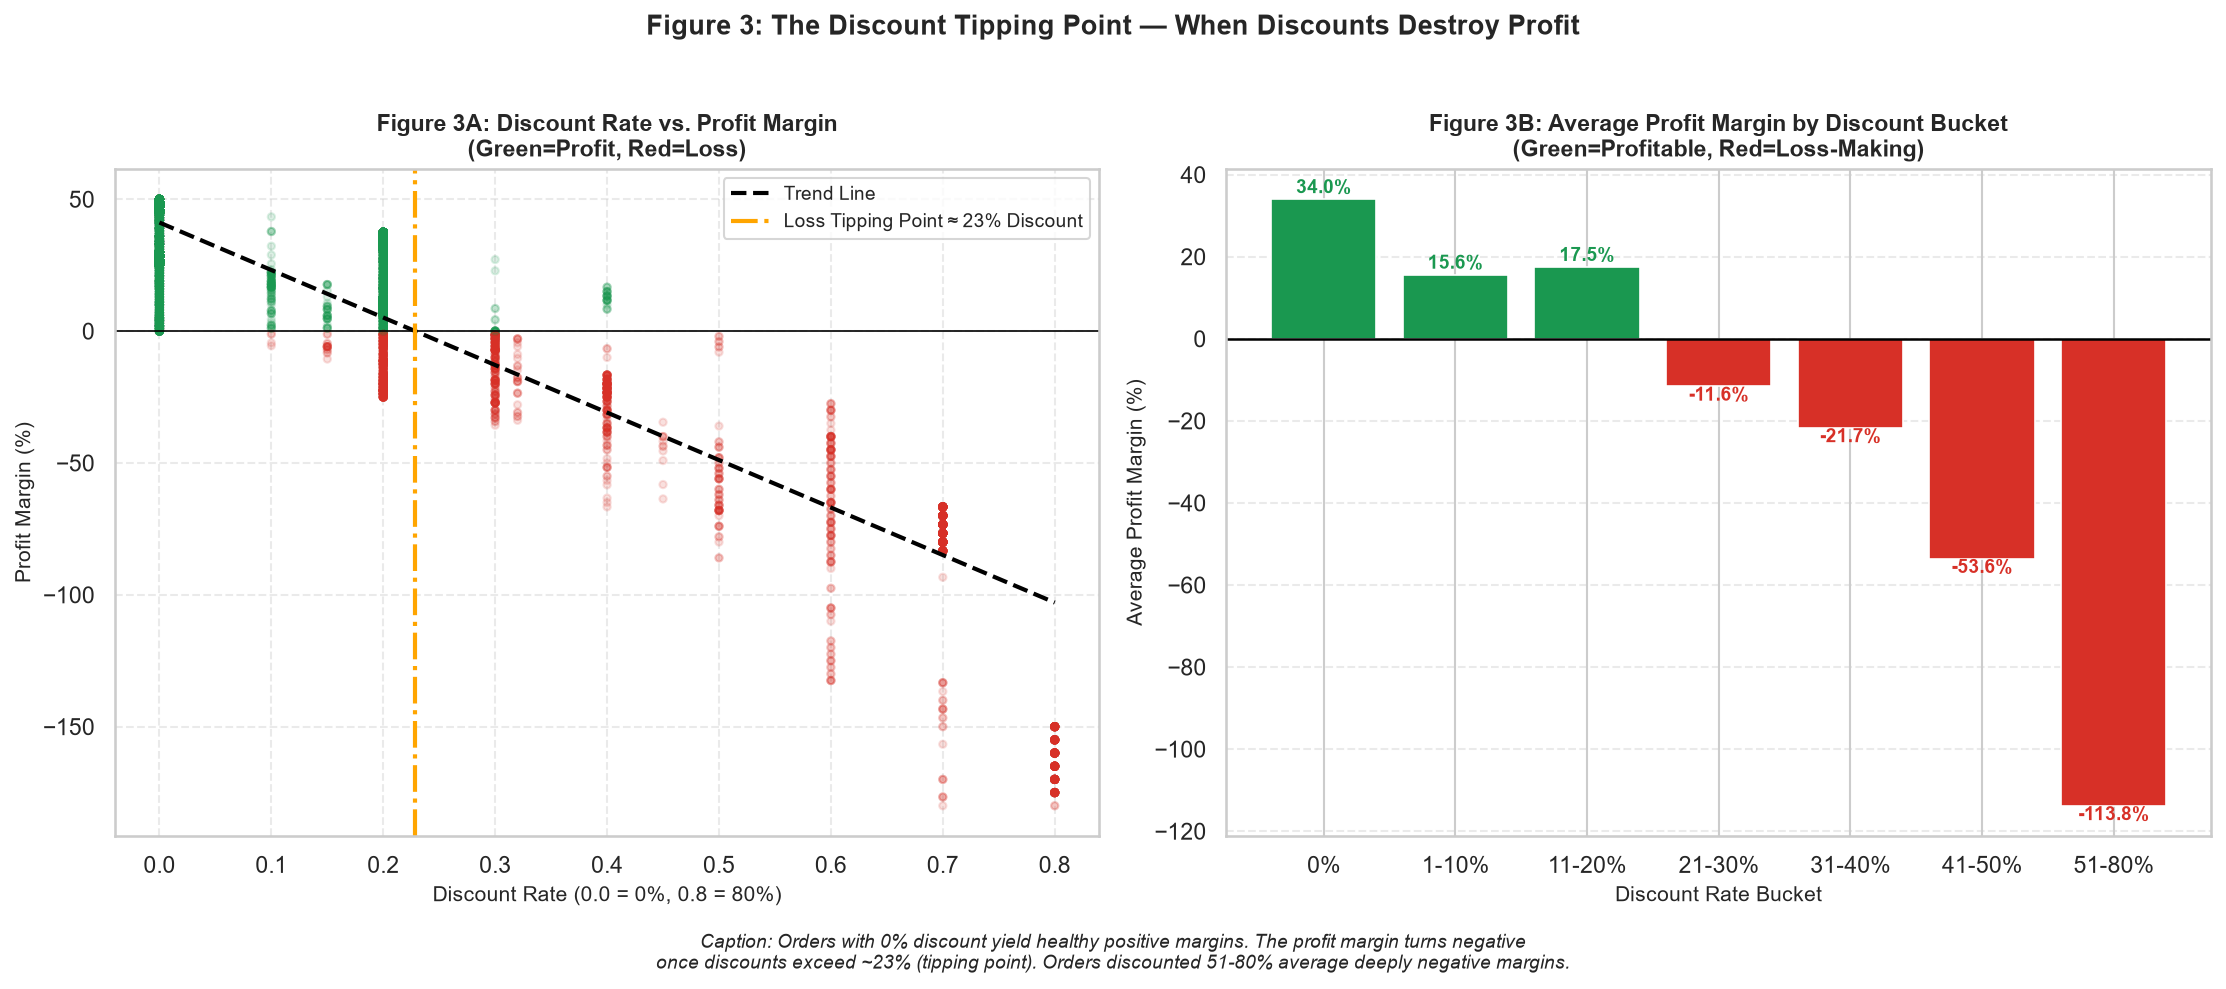


Discount Tipping Point (where margin crosses zero): ~22.9%

--- Average Profit Margin by Discount Bucket ---
Discount_Bucket  Profit_Margin
             0%      34.001253
          1-10%      15.579196
         11-20%      17.465289
         21-30%     -11.580278
         31-40%     -21.690651
         41-50%     -53.558442
         51-80%    -113.807018


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Left: Scatter of Discount vs Profit Margin (all orders, clipped for clarity)
plot_df = df[df['Profit_Margin'].between(-200, 200)].copy()

scatter = axes[0].scatter(plot_df['Discount'], plot_df['Profit_Margin'],
                          alpha=0.15, s=12, 
                          c=plot_df['Profit_Margin'].apply(lambda x: '#d73027' if x < 0 else '#1a9850'))

# Add regression trend line
import numpy as np
z = np.polyfit(plot_df['Discount'], plot_df['Profit_Margin'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, 0.8, 200)
axes[0].plot(x_line, p(x_line), color='black', linewidth=2, linestyle='--', label='Trend Line')

# Mark the critical tipping point (where regression crosses zero)
tipping_discount = -z[1] / z[0]
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axvline(tipping_discount, color='orange', linewidth=2, linestyle='-.', 
                label=f'Loss Tipping Point ≈ {tipping_discount:.0%} Discount')

axes[0].set_title("Figure 3A: Discount Rate vs. Profit Margin\n(Green=Profit, Red=Loss)", 
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel("Discount Rate (0.0 = 0%, 0.8 = 80%)", fontsize=10)
axes[0].set_ylabel("Profit Margin (%)", fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.4)

# 2. Right: Average Profit Margin by Discount Bucket
df['Discount_Bucket'] = pd.cut(df['Discount'], 
                                bins=[-0.01, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.8],
                                labels=['0%', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '51-80%'])

bucket_stats = df.groupby('Discount_Bucket', observed=True)['Profit_Margin'].mean().reset_index()

colors = ['#1a9850' if v >= 0 else '#d73027' for v in bucket_stats['Profit_Margin']]
bars = axes[1].bar(bucket_stats['Discount_Bucket'], bucket_stats['Profit_Margin'], 
                    color=colors, edgecolor='white', linewidth=0.8)

axes[1].axhline(0, color='black', linewidth=1.2)
axes[1].set_title("Figure 3B: Average Profit Margin by Discount Bucket\n(Green=Profitable, Red=Loss-Making)", 
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel("Discount Rate Bucket", fontsize=10)
axes[1].set_ylabel("Average Profit Margin (%)", fontsize=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

for bar, val in zip(bars, bucket_stats['Profit_Margin']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + (1.5 if val >= 0 else -3.5),
                 f"{val:.1f}%", ha='center', fontsize=9, fontweight='bold',
                 color='#1a9850' if val >= 0 else '#d73027')

plt.suptitle("Figure 3: The Discount Tipping Point — When Discounts Destroy Profit",
             fontsize=13, fontweight='bold', y=1.02)
plt.figtext(0.5, -0.04,
    f"Caption: Orders with 0% discount yield healthy positive margins. The profit margin turns negative\n"
    f"once discounts exceed ~{tipping_discount:.0%} (tipping point). Orders discounted 51-80% average deeply negative margins.", 
    wrap=True, horizontalalignment='center', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

print(f"\nDiscount Tipping Point (where margin crosses zero): ~{tipping_discount:.1%}")
print("\n--- Average Profit Margin by Discount Bucket ---")
print(bucket_stats.to_string(index=False))

--- Bottom 5 & Top 5 Sub-Categories by Total Profit ---
Sub-Category  Total_Sales  Total_Profit  Avg_Discount  Avg_Margin
      Tables  206965.5320   -17725.4811      0.261285  -14.772653
   Bookcases  114879.9963    -3472.5560      0.211140  -12.664007
    Supplies   46673.5380    -1189.0995      0.076842   11.203947
 Accessories  167380.3180    41936.6357      0.078452   21.820968
      Phones  330007.0540    44515.7306      0.154556   11.922197
     Copiers  149528.0300    55617.8249      0.161765   31.719363


C:\Users\Misiko\AppData\Local\Temp\ipykernel_32064\1387545719.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


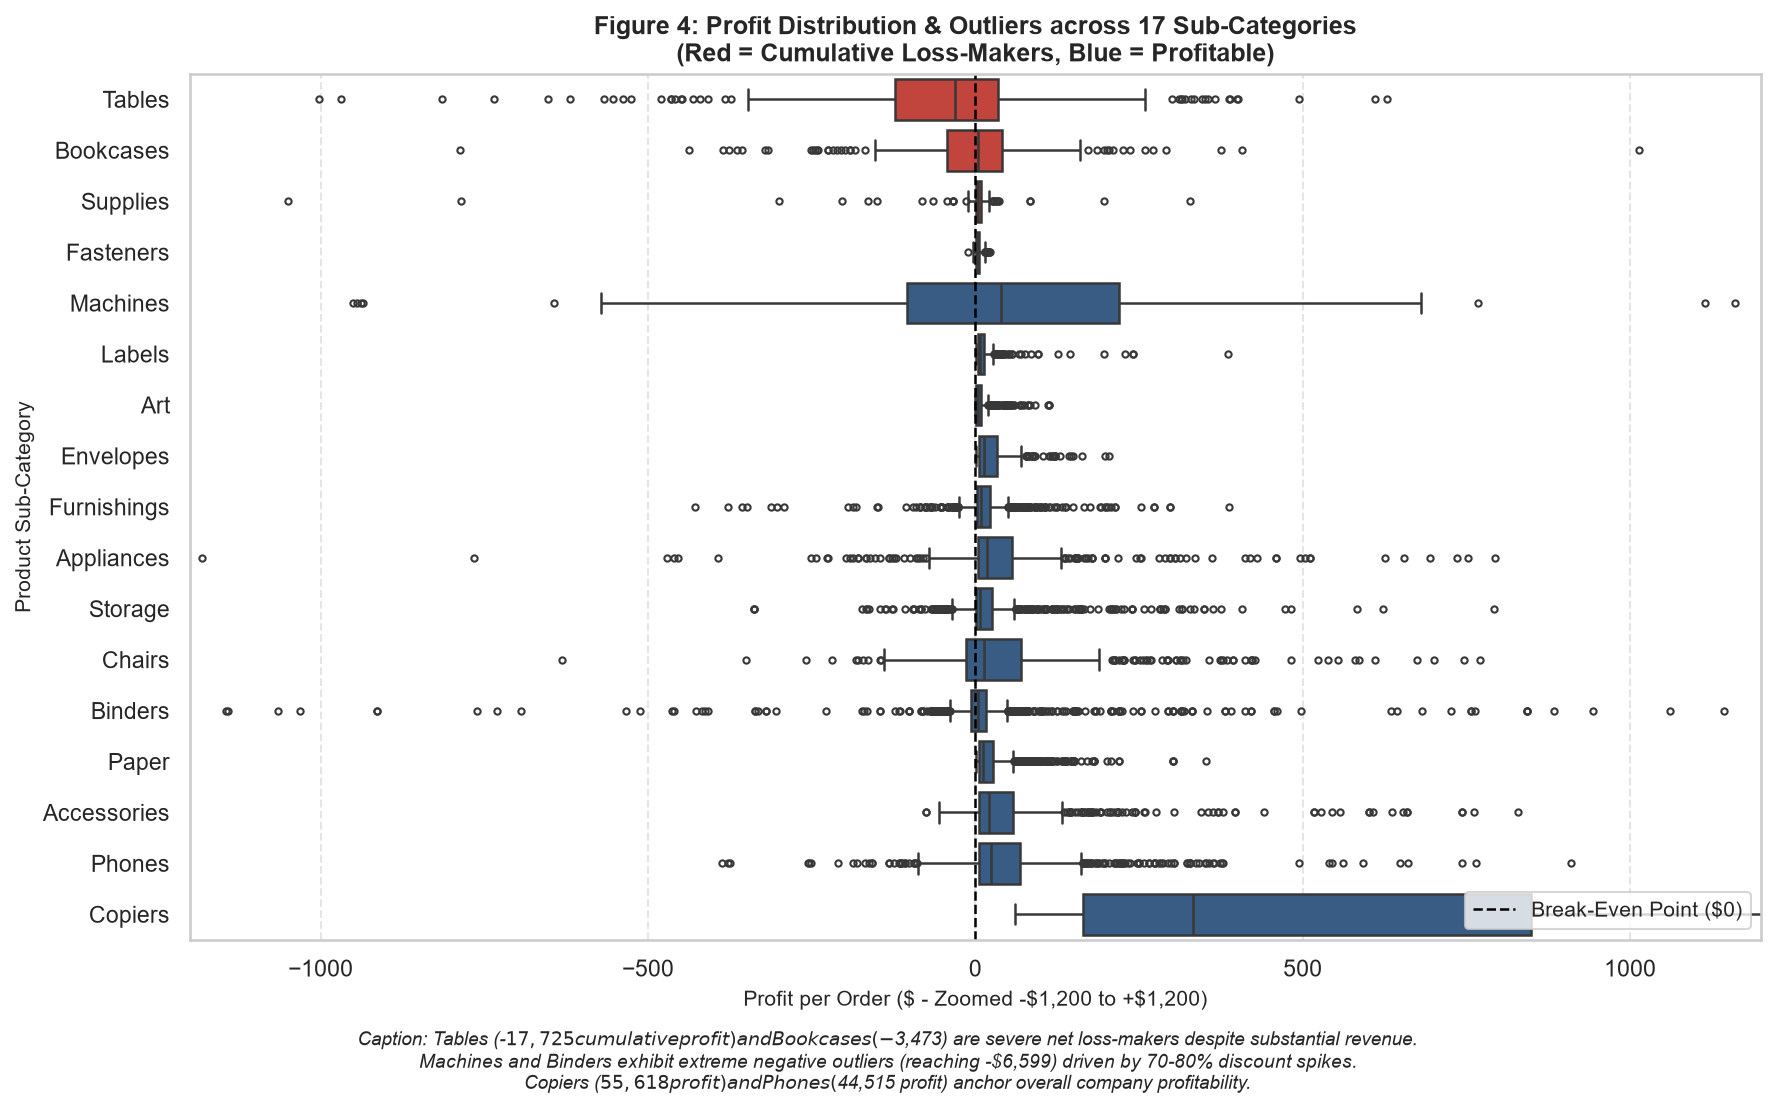

In [7]:
# 1. Aggregate Total Profit by Sub-Category to sort logically
subcat_order = df.groupby('Sub-Category')['Profit'].sum().sort_values().index

# 2. Print the exact totals for Tables, Bookcases, Supplies, and Copiers
subcat_summary = df.groupby('Sub-Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Discount=('Discount', 'mean'),
    Avg_Margin=('Profit_Margin', 'mean')
).loc[subcat_order].reset_index()

print("--- Bottom 5 & Top 5 Sub-Categories by Total Profit ---")
print(pd.concat([subcat_summary.head(3), subcat_summary.tail(3)]).to_string(index=False))

# 3. Create Horizontal Boxplot of Profit Distribution
plt.figure(figsize=(12, 7))

# Palette: highlight loss-making sub-categories in red, profitable in green/blue
palette = ['#d73027' if p < 0 else '#2b5c8f' for p in df.groupby('Sub-Category')['Profit'].sum().loc[subcat_order]]

sns.boxplot(
    data=df, 
    y='Sub-Category', 
    x='Profit', 
    order=subcat_order,
    palette=palette,
    fliersize=3,
    linewidth=1.2
)

plt.axvline(0, color='black', linestyle='--', linewidth=1.2, label='Break-Even Point ($0)')
plt.xlim(-1200, 1200) # Zoom into the meaningful range while showing outlier spread
plt.title("Figure 4: Profit Distribution & Outliers across 17 Sub-Categories\n"
          "(Red = Cumulative Loss-Makers, Blue = Profitable)", 
          fontsize=12, fontweight='bold')
plt.xlabel("Profit per Order ($ - Zoomed -$1,200 to +$1,200)", fontsize=10)
plt.ylabel("Product Sub-Category", fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(loc='lower right', fontsize=10)

plt.figtext(0.5, -0.05,
    "Caption: Tables (-$17,725 cumulative profit) and Bookcases (-$3,473) are severe net loss-makers despite substantial revenue.\n"
    "Machines and Binders exhibit extreme negative outliers (reaching -$6,599) driven by 70-80% discount spikes.\n"
    "Copiers ($55,618 profit) and Phones ($44,515 profit) anchor overall company profitability.",
    wrap=True, horizontalalignment='center', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

--- Pearson Correlation Matrix ---
               Sales  Quantity  Discount  Profit  Profit_Margin
Sales          1.000     0.201    -0.028   0.479          0.004
Quantity       0.201     1.000     0.009   0.066         -0.005
Discount      -0.028     0.009     1.000  -0.220         -0.864
Profit         0.479     0.066    -0.220   1.000          0.224
Profit_Margin  0.004    -0.005    -0.864   0.224          1.000


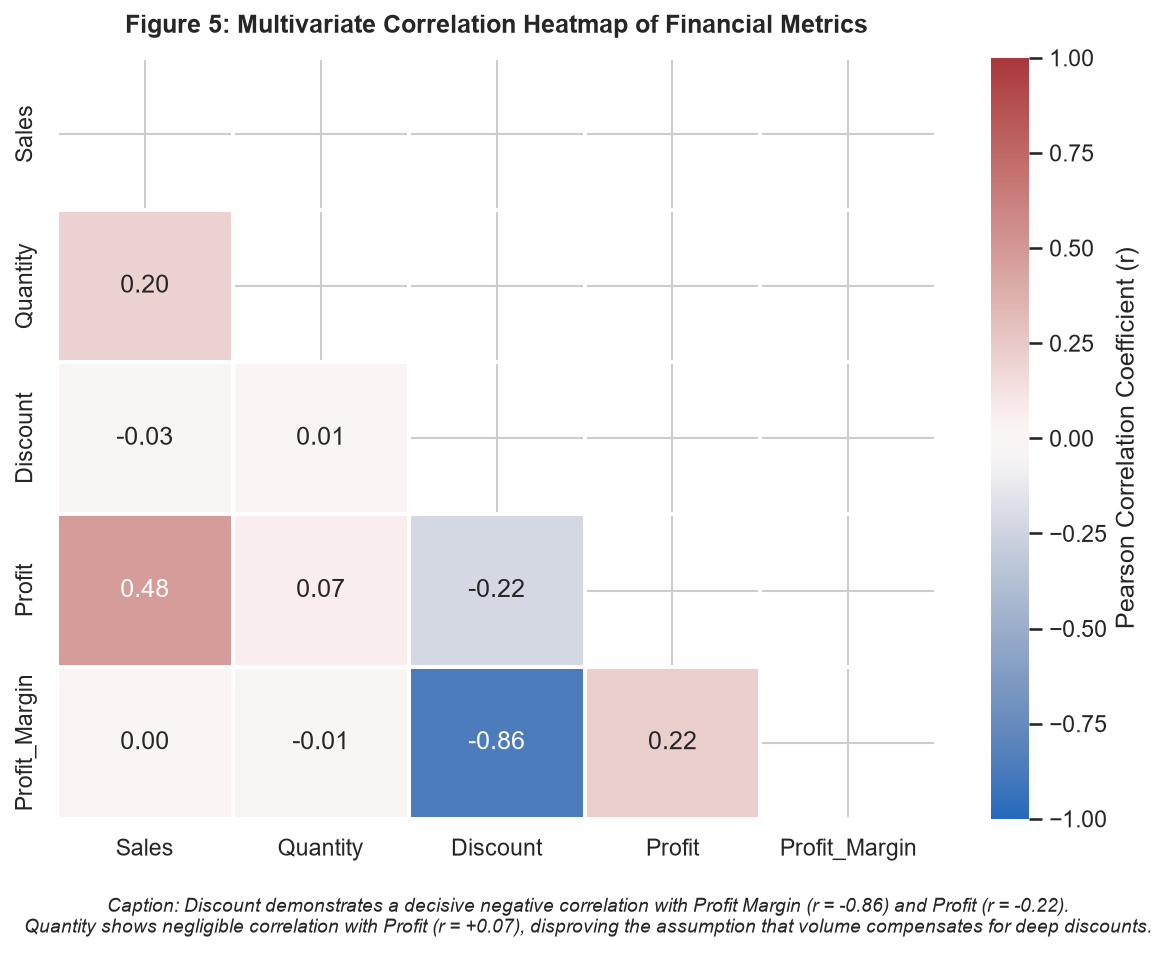

In [8]:
# 1. Compute Pearson Correlation Matrix
corr_vars = ['Sales', 'Quantity', 'Discount', 'Profit', 'Profit_Margin']
corr_matrix = df[corr_vars].corr()

print("--- Pearson Correlation Matrix ---")
print(corr_matrix.round(3))

# 2. Render Correlation Heatmap
plt.figure(figsize=(8, 6))

# Mask the upper triangle for clean, uncluttered presentation
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt=".2f", 
    cmap="vlag", 
    vmin=-1.0, 
    vmax=1.0, 
    linewidths=1, 
    cbar_kws={"label": "Pearson Correlation Coefficient (r)"}
)

plt.title("Figure 5: Multivariate Correlation Heatmap of Financial Metrics", 
          fontsize=12, fontweight='bold', pad=12)

plt.figtext(0.5, -0.05,
    "Caption: Discount demonstrates a decisive negative correlation with Profit Margin (r = -0.86) and Profit (r = -0.22).\n"
    "Quantity shows negligible correlation with Profit (r = +0.07), disproving the assumption that volume compensates for deep discounts.",
    wrap=True, horizontalalignment='center', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

# Executive Data Story: The Discount Paradox — Rescuing Profitability in E-Commerce Retail

**Author:** Misiko  
**Dataset:** Sample Superstore (9,977 Cleaned Transactions)  
**Track:** Track I: AI Data Science — Gate I1  

---

### 1. Executive Summary & Problem Context
An analysis of 9,977 retail transactions revealed a stark operational paradox: while the Superstore achieved strong top-line revenue of **$2.29M**, net profit reached only **$286K** (an overall margin of 12.5%). Most critically, **18.7% of all customer orders (1,869 transactions) actively lost money**, generating cumulative net losses exceeding $156,000. 

Rather than a broad market failure, these losses are driven by a specific, unmonitored promotional practice: **unrestricted discount stacking**.

---

### 2. Core Empirical Findings (Referencing Visual Evidence)

1. **The Negative Profit Tail & Asymmetric Skew (Figure 1):**
   Order sales exhibit extreme positive skewness (median: $54.82, mean: $229.86), while order profits show an alarming left-hand loss tail extending down to a maximum single-order loss of **-$6,599.98**. Median profit per order sits at a meager **$8.67**, meaning the business relies on high transaction velocity with razor-thin buffers.

2. **The Category Profitability Divergence (Figure 2):**
   While **Technology** generated **$836K** in sales and delivered **$145K** in net profit (a strong **17.4% margin**), **Furniture** generated comparable sales volume of **$741K** but returned only **$18.4K** in net profit — an abysmal **2.5% margin**. Furniture consumes 32.3% of total revenue capacity while contributing just 6.4% of net earnings.

3. **The Discount Tipping Point at 22.9% (Figure 3):**
   Analyzing profit margins against discount rates isolates the root cause. At 0% discount, transactions average a healthy **+34.0% margin**. Between 11% and 20% discount, margins remain sustainable at **+17.5%**. However, at **~22.9% discount**, profitability crosses the zero-threshold. Orders discounted between 21% and 30% average **-11.6% margin**, and orders discounted above 50% collapse to **-113.8% margin**.

4. **Chronic Loss-Making Sub-Categories (Figure 4):**
   Drilling into sub-categories exposes that the Furniture margin collapse is driven almost entirely by **Tables** (total sales: **$206.9K**, net profit: **-$17,725.48**, average discount: **26.1%**) and **Bookcases** (net profit: **-$3,472.56**, average discount: **21.1%**). Both lines operate above the 22.9% loss threshold, whereas top-performing lines like **Copiers** (+$55.6K profit, 31.7% margin) and **Accessories** (+$41.9K profit, 21.8% margin) maintain discounts well below 17%.

5. **The Volume Fallacy (Figure 5):**
   Correlation analysis firmly disproves the commercial assumption that discounting drives compensatory volume. Discount correlates strongly negatively with Profit Margin (**r = -0.864**), while Quantity correlates virtually at zero with Profit (**r = +0.066**). Pushing more volume at discounted rates simply accelerates capital loss.

---

### 3. Strategic & Actionable Recommendations

1. **Hard-Cap Discretionary Discounts at 20%:**  
   Immediately eliminate all automated discounts exceeding 20% across all channels. Because the empirical tipping point is 22.9%, capping promotions at 20% immediately halts the 1,869 loss-making transactions without sacrificing customer acquisition.
2. **Re-Engineer Tables & Bookcases Pricing:**  
   Place Tables and Bookcases on a specialized margin-floor contract. Given their baseline negative margins (-14.8% and -12.7%), restrict promotional discounts to a maximum of 10%, bundle them with high-margin items (e.g. Office Supplies, Accessories), or renegotiate supplier freight costs.
3. **Incentivize Sales Teams on Net Profit, Not Gross Revenue:**  
   Sales representatives currently utilize 70–80% discounts to close high-dollar enterprise sales (creating extreme outliers like the -$6,599 transaction). Align commission structures with net delivered margin rather than top-line gross transaction volume.